In [186]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.fft import fft, ifft
import pandas as pd
import glob
import sipm.util.functions as func
from datetime import datetime
from scipy.optimize import least_squares
plt.style.use('darkside')
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
!pwd

/home/as111/sipm-analysis/jupyter


# SiPM SPE Template

In [187]:
# data folder
path = "/scratch/gpfs/GALBIATI/as111/results/2023-12-13"
data_spe = {}
channels = np.arange(8)
volt = 98
for ch in channels:
    data_spe[ch] = {'n_spe_wfs':0, 'avg_spe_wf':np.zeros(0), 'time':np.zeros(0)}
    files = glob.glob(f"{path}/*volt_{volt}*laser_waveform_liq5.h5")
    # files = glob.glob(f"{path}/*volt_{volt}*laser_waveform_liq5_nocut.h5")
    print(files)
    for f in files:
        df = pd.read_hdf(f, key=f'{volt}/{ch}')
        data_spe[ch]['n_spe_wfs'] += np.array(df['n_spe_wfs'])[0]
        if data_spe[ch]['time'].shape[0]==0:
            data_spe[ch]['time'] = np.array(df['time'])
        if np.array(df['n_spe_wfs'])[0]>0:
            if data_spe[ch]['avg_spe_wf'].shape[0]==0:
                data_spe[ch]['avg_spe_wf'] = np.array(df['avg_spe_wf'])*np.array(df['n_spe_wfs'])[0]
            else:
                data_spe[ch]['avg_spe_wf'] += np.array(df['avg_spe_wf'])*np.array(df['n_spe_wfs'])[0]
    df = None
    if data_spe[ch]['n_spe_wfs']>0:
        data_spe[ch]['avg_spe_wf'] /= data_spe[ch]['n_spe_wfs']

['/scratch/gpfs/GALBIATI/as111/results/2023-12-13/2023-12-13_volt_98_light_laser_cond_ar_run0_laser_waveform_liq5.h5', '/scratch/gpfs/GALBIATI/as111/results/2023-12-13/2023-12-13_volt_98_light_laser_cond_ar_run5_laser_waveform_liq5.h5', '/scratch/gpfs/GALBIATI/as111/results/2023-12-13/2023-12-13_volt_98_light_laser_cond_ar_run3_laser_waveform_liq5.h5', '/scratch/gpfs/GALBIATI/as111/results/2023-12-13/2023-12-13_volt_98_light_laser_cond_ar_run4_laser_waveform_liq5.h5', '/scratch/gpfs/GALBIATI/as111/results/2023-12-13/2023-12-13_volt_98_light_laser_cond_ar_run8_laser_waveform_liq5.h5', '/scratch/gpfs/GALBIATI/as111/results/2023-12-13/2023-12-13_volt_98_light_laser_cond_ar_run2_laser_waveform_liq5.h5', '/scratch/gpfs/GALBIATI/as111/results/2023-12-13/2023-12-13_volt_98_light_laser_cond_ar_run9_laser_waveform_liq5.h5', '/scratch/gpfs/GALBIATI/as111/results/2023-12-13/2023-12-13_volt_98_light_laser_cond_ar_run6_laser_waveform_liq5.h5', '/scratch/gpfs/GALBIATI/as111/results/2023-12-13/2023-1

ch0 98V 52313 waveforms selected. Trigger position = 6.364000 us
ch1 98V 81455 waveforms selected. Trigger position = 6.364000 us
ch2 98V 71758 waveforms selected. Trigger position = 6.364000 us
ch3 98V 93199 waveforms selected. Trigger position = 6.364000 us
ch4 98V 97203 waveforms selected. Trigger position = 6.364000 us
ch5 98V 80383 waveforms selected. Trigger position = 6.364000 us
ch6 98V 35771 waveforms selected. Trigger position = 6.364000 us
ch7 98V 30426 waveforms selected. Trigger position = 6.368000 us


Text(0.07, 0.5, 'Amplitude (ADC Unit)')

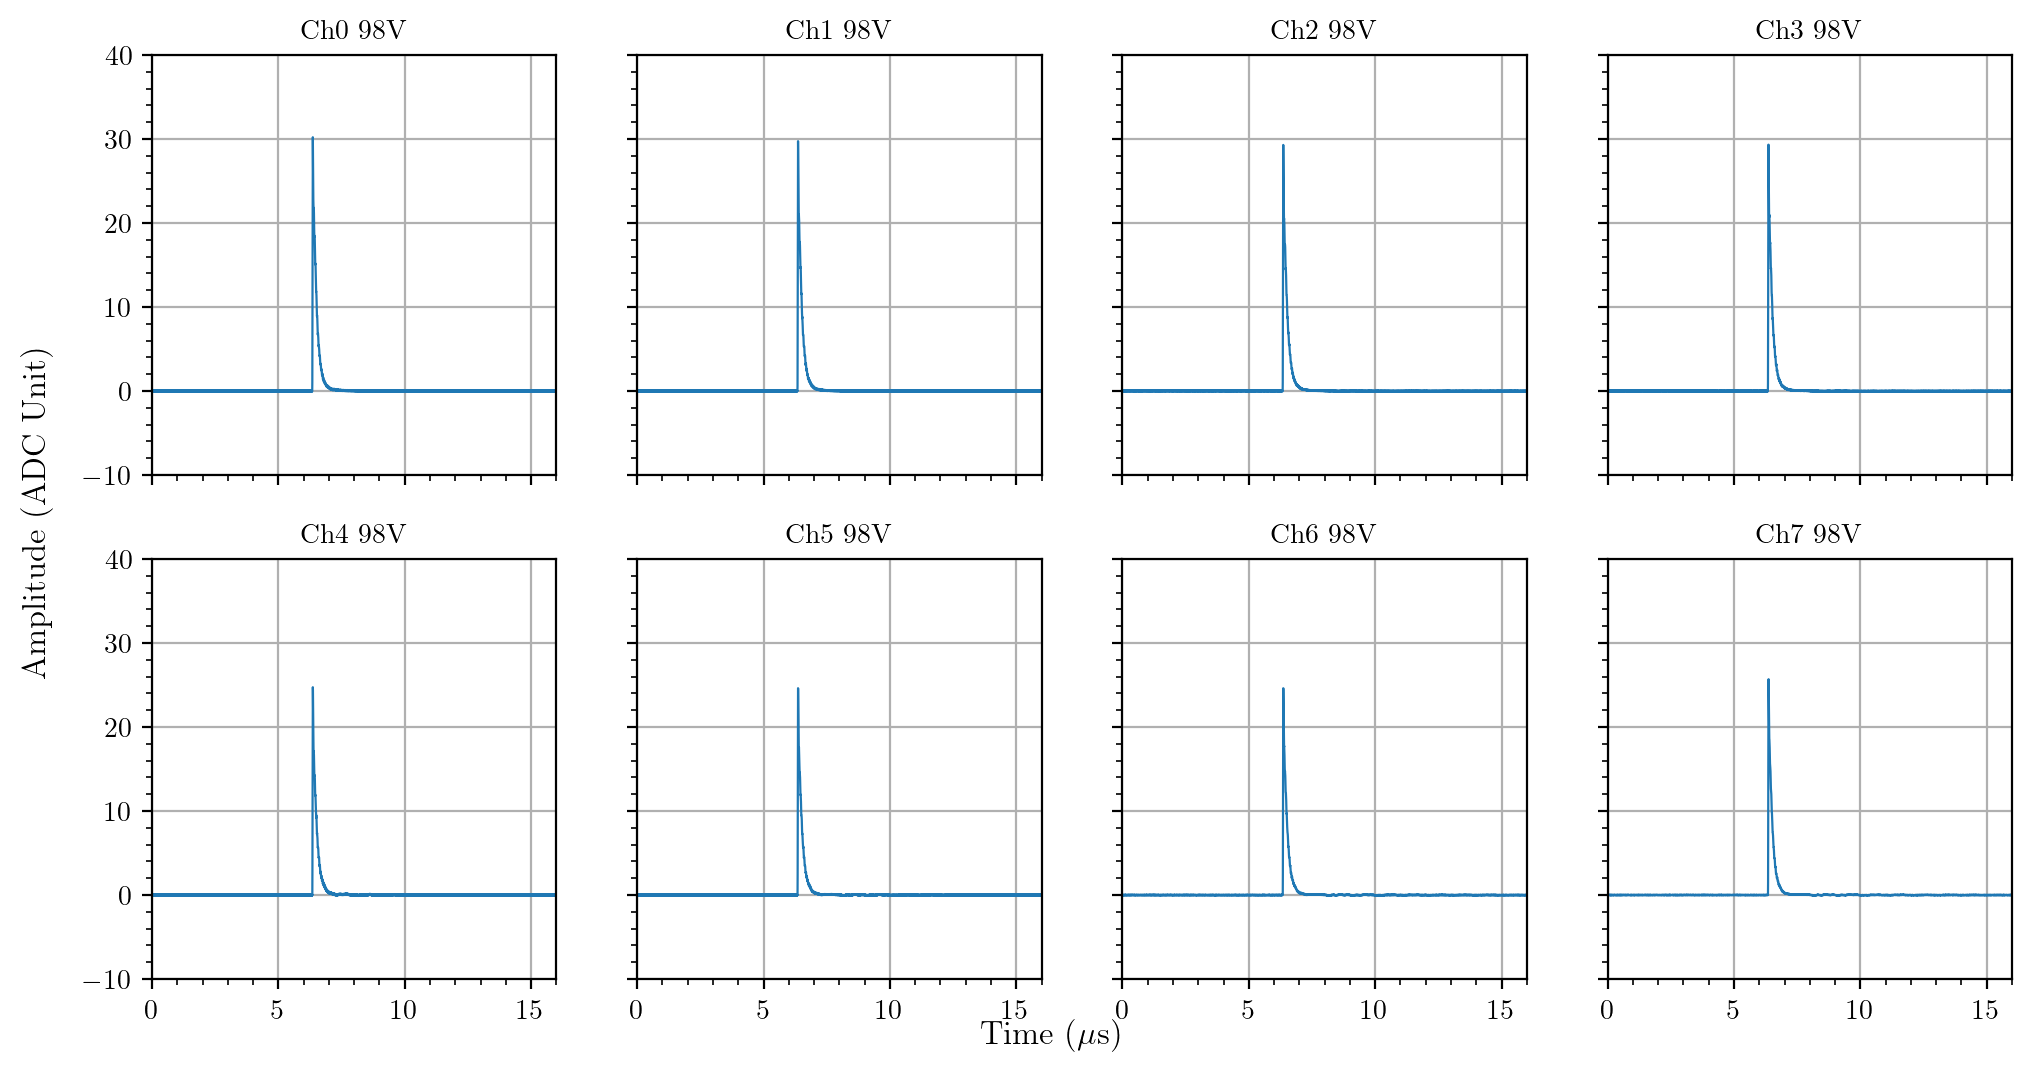

In [188]:
# Make plots for all datasets
# SPE average waveform
t0_spe = {}
fig, axs = plt.subplots(2, 4, sharex=True, sharey=True)
fig.set_size_inches(12, 6)
for j, ch in enumerate(channels):
    if data_spe[ch]['n_spe_wfs']>0:
        t0_spe[ch] = data_spe[ch]['time'][np.argmax(data_spe[ch]['avg_spe_wf'])]
        print(f'ch{ch} {volt}V {data_spe[ch]["n_spe_wfs"]:.0f} waveforms selected. Trigger position = {t0_spe[ch]:2f} us')
        axs[j//4, j%4].plot(
            data_spe[ch]['time'],
            data_spe[ch]['avg_spe_wf'],linewidth=0.8)
    axs[j//4, j%4].set_xlim(0, 16)
    # axs[j//4, j%4].set_ylim(-3e-1, 4e-1)
    # axs[j//4, j%4].set_yscale('log')
    axs[j//4, j%4].minorticks_on()
    axs[j//4, j%4].grid()
    axs[j//4, j%4].set_title(f'Ch{ch} {volt}V')
fig.supxlabel(r'Time ($\mu$s)', y=0.05)
fig.supylabel(r'Amplitude (ADC Unit)', x=0.07)

## FFT

Text(0.07, 0.5, 'FFT Abs. Amplitude (ADC Unit)')

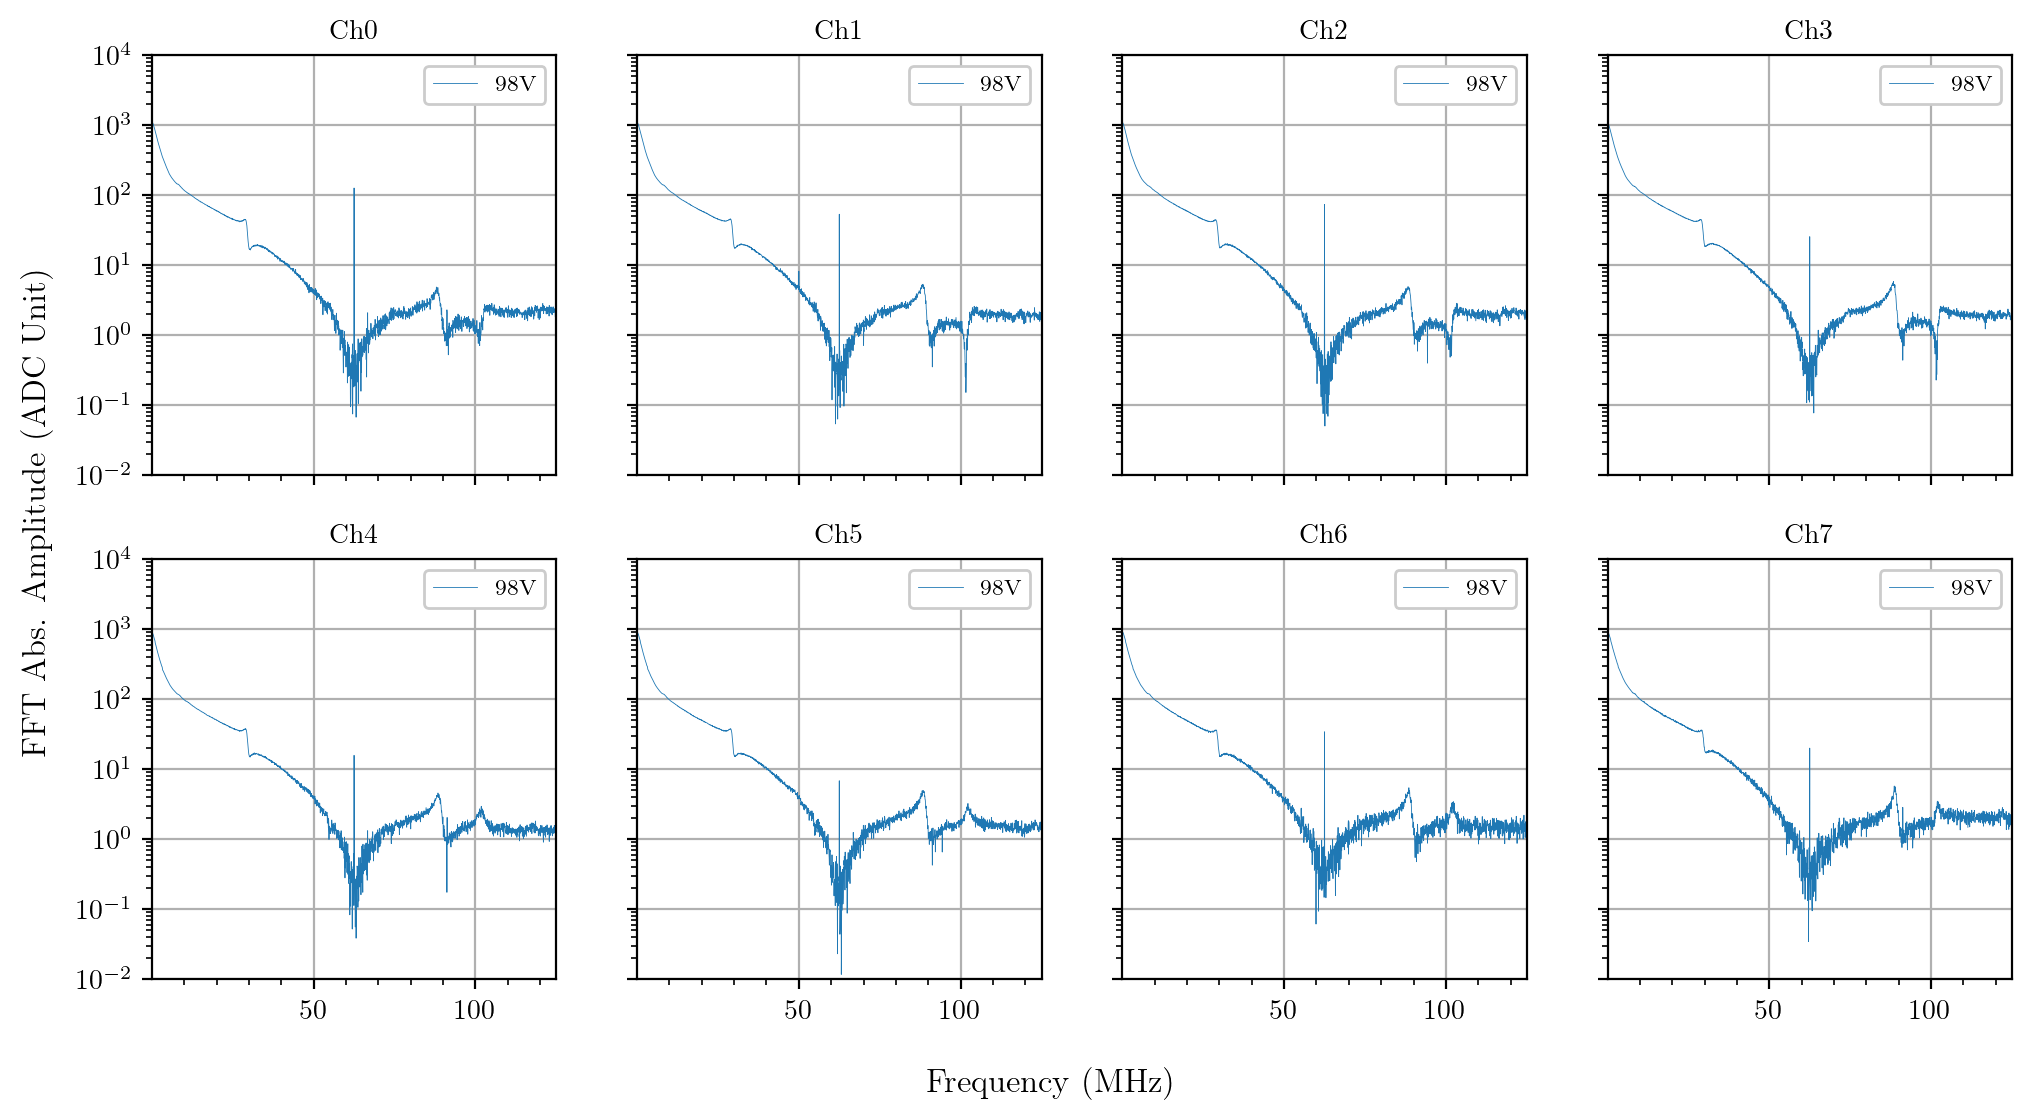

In [189]:
# Make plots for all datasets
# SPE average waveform
fig, axs = plt.subplots(2, 4, sharex=True, sharey=True)
fig.set_size_inches(12, 6)
for j, ch in enumerate(channels):
    data_spe[ch]['fft_spe_wf'] = fft(data_spe[ch]['avg_spe_wf'])
    dt = data_spe[ch]['time'][1]-data_spe[ch]['time'][0]
    t_total = dt+data_spe[ch]['time'][-1]
    n_over_2 = int(data_spe[ch]['time'].shape[0]/2)
    data_spe[ch]['frequency'] = data_spe[ch]['time']/dt/t_total
    axs[j//4, j%4].plot(
        data_spe[ch]['frequency'][:n_over_2],
        abs(data_spe[ch]['fft_spe_wf'][:n_over_2]),
        label=f'{volt}V', linewidth=0.3)
    axs[j//4, j%4].legend(loc='upper right')
    axs[j//4, j%4].set_xlim(data_spe[ch]['frequency'][1], data_spe[ch]['frequency'][n_over_2])
    axs[j//4, j%4].set_ylim(1e-2, 1e4)
    axs[j//4, j%4].set_yscale('log')
    axs[j//4, j%4].minorticks_on()
    axs[j//4, j%4].grid()
    axs[j//4, j%4].set_title(f'Ch{ch}')
fig.supxlabel(r'Frequency (MHz)', y=0.01)
fig.supylabel(r'FFT Abs. Amplitude (ADC Unit)', x=0.07)

# Pulse Shape Fit 1: Estimate Reaction Rate Constant

$$\tau_{\rm ArXe}^{\prime -1} = \tau_{\rm ArXe}^{-1} + kc$$

* $k$: reaction rate constant
* $c$: Xe concentration
* $\tau_{\rm ArXe}$: Original $\rm ArXe^\ast$ lifetime
* $\tau_{\rm ArXe}^{\prime}$: Measured $\rm ArXe^\ast$ quenched lifetime

## Load data

Use equilibrium concentration Na-22 data

In [318]:
path = "/scratch/gpfs/GALBIATI/as111/results/"
cond = ['Na22 0ppm','Na22 2.7ppm','Na22 5.0ppm', 'Na22 10ppm', 'Na22 20ppm', 'Na22 40ppm']
conc = np.array([float(c.split(' ')[1].split('ppm')[0]) for c in cond])
files = [[],[],[],[],[],[]]
files[0].extend(glob.glob(f"{path}2024-02-23/*cond_gamma*source_na22*xenon_0*scintillation_waveform_liq6.h5"))
files[1].extend(glob.glob(f"{path}2024-03-06/*cond_gamma*source_na22*xenon_1*scintillation_waveform_liq6.h5"))
files[2].extend(glob.glob(f"{path}2024-03-12/*cond_gamma*source_na22*xenon_2*scintillation_waveform_liq6.h5"))
files[3].extend(glob.glob(f"{path}2024-03-19/*cond_gamma*source_na22*xenon_3*scintillation_waveform_liq6.h5"))
files[4].extend(glob.glob(f"{path}2024-03-25/*cond_gamma*source_na22*xenon_4*scintillation_waveform_liq6.h5"))
files[5].extend(glob.glob(f"{path}2024-04-01/*cond_gamma*source_na22*xenon_5*scintillation_waveform_liq6.h5"))
print(len(files[0]),files[0])
print(len(files[1]),files[1])
print(len(files[2]),files[2])
print(len(files[3]),files[3])
print(len(files[4]),files[4])
print(len(files[5]),files[5])

10 ['/scratch/gpfs/GALBIATI/as111/results/2024-02-23/2024-02-23_volt_98_light_scintillation_cond_gamma_source_na22_xenon_0_run1_scintillation_waveform_liq6.h5', '/scratch/gpfs/GALBIATI/as111/results/2024-02-23/2024-02-23_volt_98_light_scintillation_cond_gamma_source_na22_xenon_0_run6_scintillation_waveform_liq6.h5', '/scratch/gpfs/GALBIATI/as111/results/2024-02-23/2024-02-23_volt_98_light_scintillation_cond_gamma_source_na22_xenon_0_run3_scintillation_waveform_liq6.h5', '/scratch/gpfs/GALBIATI/as111/results/2024-02-23/2024-02-23_volt_98_light_scintillation_cond_gamma_source_na22_xenon_0_run8_scintillation_waveform_liq6.h5', '/scratch/gpfs/GALBIATI/as111/results/2024-02-23/2024-02-23_volt_98_light_scintillation_cond_gamma_source_na22_xenon_0_run9_scintillation_waveform_liq6.h5', '/scratch/gpfs/GALBIATI/as111/results/2024-02-23/2024-02-23_volt_98_light_scintillation_cond_gamma_source_na22_xenon_0_run5_scintillation_waveform_liq6.h5', '/scratch/gpfs/GALBIATI/as111/results/2024-02-23/2024-

In [319]:
# data folder
data_scint = {}
date_time = {}
channels = np.arange(8)
channels_nofs = [1,2,4,7] 
channels_fs = [0,3,6]
ch_old = [0,5,6,3,4,1,2,7] # map to channels in liq5 calibration data
volt = 98
for i,fs in enumerate(files):
    data_scint[i] = {}
    for j,f in enumerate(fs):
        df = pd.read_hdf(f, key=f'{volt}/-1')
        if j==0:
            date_time[i] = datetime(*np.array(df['start_datetime'][:6]).astype(int))
        for ch in channels:
            if j==0:
                data_scint[i][ch] = {'n_scint_wfs':0, 'avg_scint_wf':np.zeros(0), 'time':np.zeros(0)}
            df = pd.read_hdf(f, key=f'{volt}/{ch}')
            data_scint[i][ch]['n_scint_wfs'] += np.array(df['n_scint_wfs'])[0]
            if data_scint[i][ch]['time'].shape[0]==0:
                data_scint[i][ch]['time'] = np.array(df['time'].dropna())
            if data_scint[i][ch]['avg_scint_wf'].shape[0]==0:
                data_scint[i][ch]['avg_scint_wf'] = np.array(df['avg_scint_wf'].dropna())*np.array(df['n_scint_wfs'])[0]
            else:
                data_scint[i][ch]['avg_scint_wf'] += np.array(df['avg_scint_wf'].dropna())*np.array(df['n_scint_wfs'])[0]
            df = None
            data_scint[i][ch]['avg_scint_wf'] /= data_scint[i][ch]['n_scint_wfs']

Na22 0ppm ch0 133761 waveforms selected
Na22 2.7ppm ch0 45378 waveforms selected
Na22 5.0ppm ch0 47925 waveforms selected
Na22 10ppm ch0 51215 waveforms selected
Na22 20ppm ch0 52816 waveforms selected
Na22 40ppm ch0 52113 waveforms selected
Na22 0ppm ch1 133761 waveforms selected
Na22 2.7ppm ch1 45378 waveforms selected
Na22 5.0ppm ch1 47925 waveforms selected
Na22 10ppm ch1 51215 waveforms selected
Na22 20ppm ch1 52816 waveforms selected
Na22 40ppm ch1 52113 waveforms selected
Na22 0ppm ch2 133761 waveforms selected
Na22 2.7ppm ch2 45378 waveforms selected
Na22 5.0ppm ch2 47925 waveforms selected
Na22 10ppm ch2 51215 waveforms selected
Na22 20ppm ch2 52816 waveforms selected
Na22 40ppm ch2 52113 waveforms selected
Na22 0ppm ch3 133761 waveforms selected
Na22 2.7ppm ch3 45378 waveforms selected
Na22 5.0ppm ch3 47925 waveforms selected
Na22 10ppm ch3 51215 waveforms selected
Na22 20ppm ch3 52816 waveforms selected
Na22 40ppm ch3 52113 waveforms selected
Na22 0ppm ch4 133761 waveforms s

Text(0.07, 0.5, 'Amplitude (ADC Unit)')

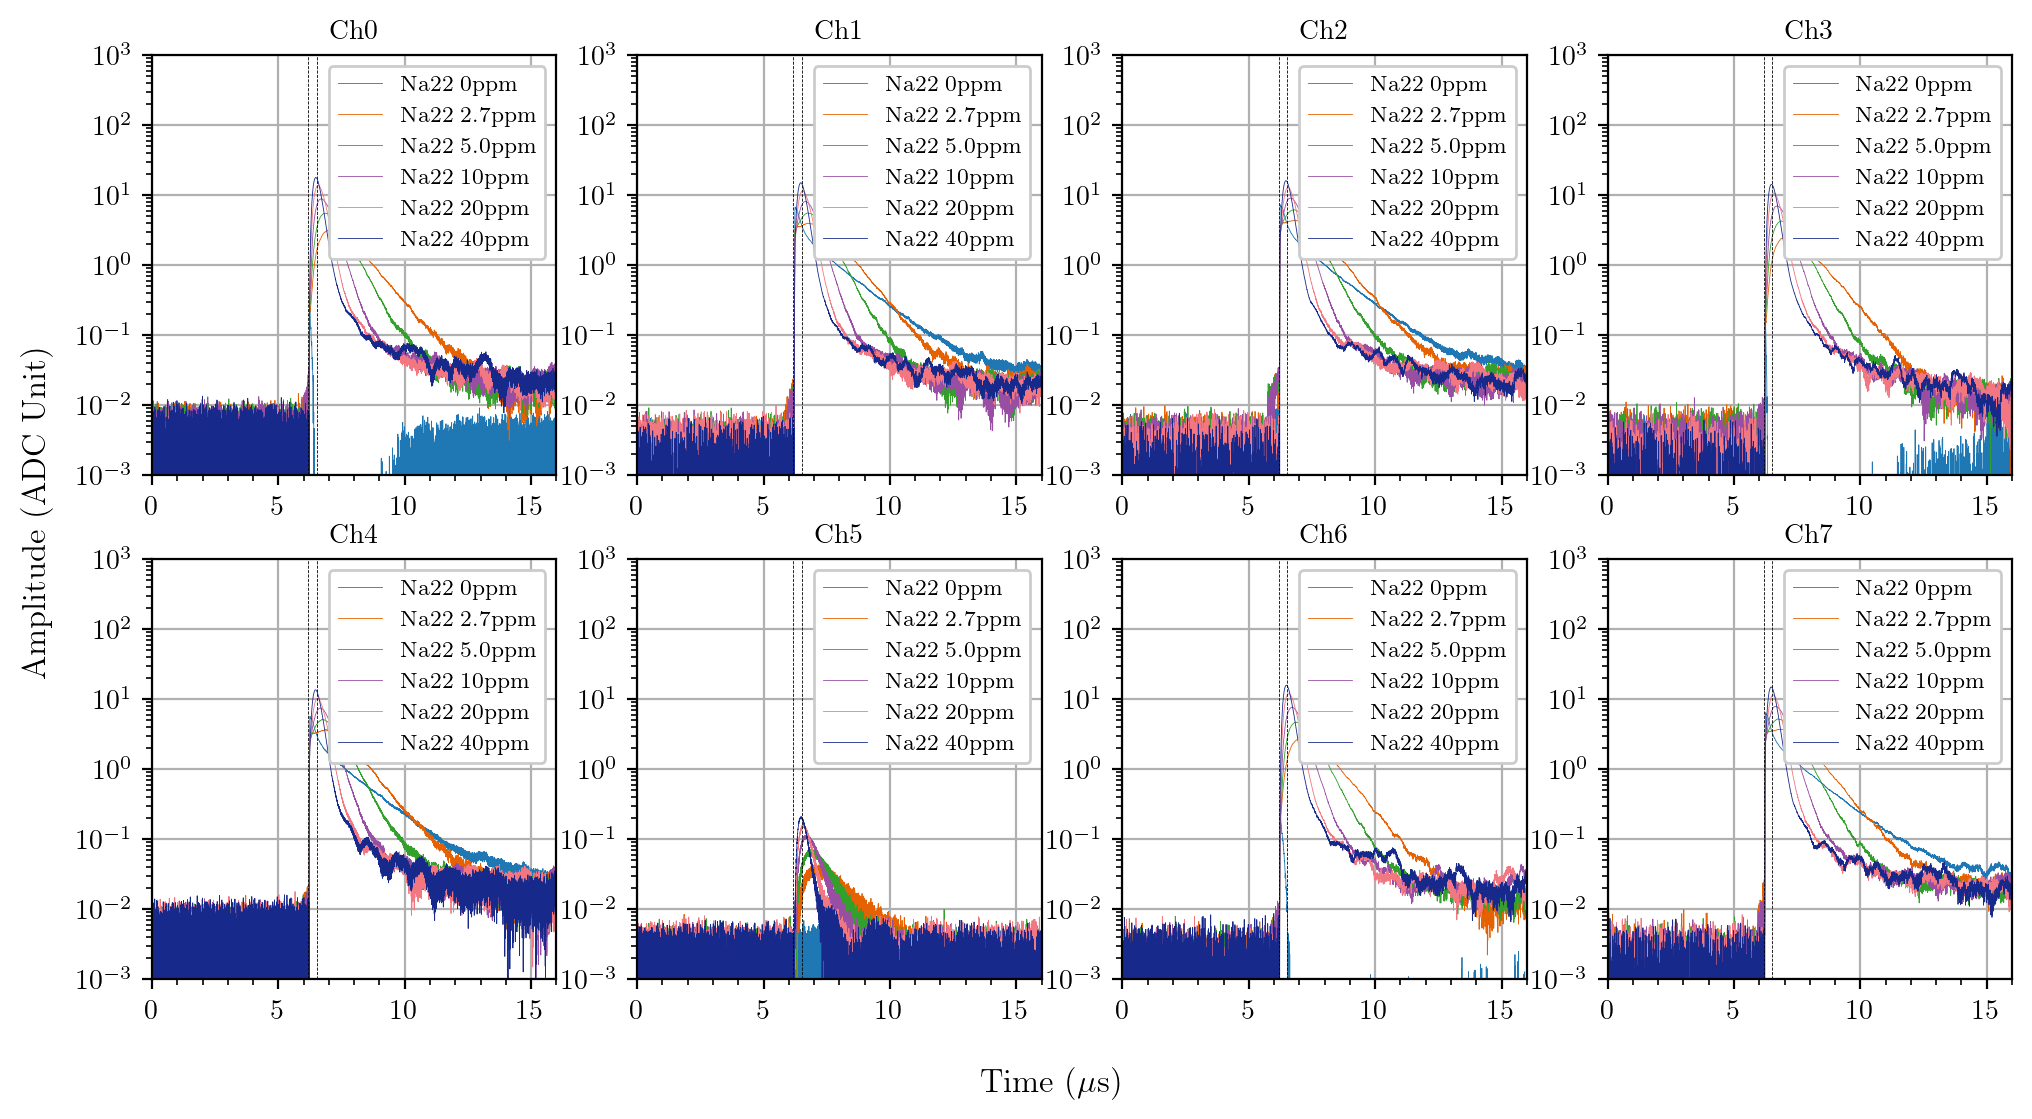

In [320]:
# Make plots for all datasets
# Average LAr scintillation waveform
t_trig = 6.22
ylims = (1e-3,1e3)
fig, axs = plt.subplots(2, 4, sharex=False, sharey=False)
fig.set_size_inches(12, 6)
for j, ch in enumerate(channels):
    for k, c in enumerate(cond):
        print(f'{c} ch{ch} {data_scint[k][ch]["n_scint_wfs"]:.0f} waveforms selected')
        axs[j//4, j%4].plot(
            data_scint[k][ch]['time'],
            data_scint[k][ch]['avg_scint_wf'],
            label=f'{c}', color=f'C{k}', linewidth=0.3)
    axs[j//4, j%4].legend(loc='upper right',fontsize=8)
    axs[j//4, j%4].set_xlim(0, 16)
    axs[j//4, j%4].set_ylim(*ylims)
    axs[j//4, j%4].set_yscale('log')
    axs[j//4, j%4].minorticks_on()
    axs[j//4, j%4].grid()
    axs[j//4, j%4].set_title(f'Ch{ch}')
    axs[j//4, j%4].plot([t_trig-10*0.004]*2, ylims, 'k--',linewidth=0.3)
    axs[j//4, j%4].plot([t_trig+0.3]*2, ylims, 'k--',linewidth=0.3)
fig.supxlabel(r'Time ($\mu$s)', y=0.01)
fig.supylabel(r'Amplitude (ADC Unit)', x=0.07)

## Processing

* Deconvolution channel-by-channel
* Sum over channels (WL and WW respectively)
* Down-sampling

In [321]:
# Deconvolution channel by channel
for i, f in enumerate(files):
    for j, ch in enumerate(channels):
        if data_scint[i][ch]['n_scint_wfs']>0 and data_spe[ch_old[ch]]['n_spe_wfs']>0:
            dt = data_spe[ch_old[ch]]['time'][1]-data_spe[ch_old[ch]]['time'][0]
            shift = np.array([np.exp(complex(0,-2*np.pi*freq*dt*int(t0_spe[ch_old[ch]]/dt))) for freq in data_spe[ch_old[ch]]['frequency']])
            data_scint[i][ch]['deconv'] = ifft(fft(data_scint[i][ch]['avg_scint_wf'])/data_spe[ch_old[ch]]['fft_spe_wf']*shift).real

In [322]:
# summation
for i,f in enumerate(files):
    data_scint[i][-1] = {'time': data_scint[i][0]['time'], 'sum_wf_nofs': np.zeros(data_scint[i][0]['time'].shape[0]),'sum_wf_fs': np.zeros(data_scint[i][0]['time'].shape[0])}
    for ch in channels_nofs:    
        if data_scint[i][ch]['n_scint_wfs']>0 and data_spe[ch]['n_spe_wfs']>0:
            data_scint[i][-1]['sum_wf_nofs'] += data_scint[i][ch]['deconv']
    for ch in channels_fs:
        if data_scint[i][ch]['n_scint_wfs']>0 and data_spe[ch]['n_spe_wfs']>0:
            data_scint[i][-1]['sum_wf_fs'] += data_scint[i][ch]['deconv']

In [323]:
# down-sampling
nsub = 4
for i,f in enumerate(files):
    data_scint[i][-1]['time_sub'], data_scint[i][-1]['sum_wf_sub_nofs'] = func.downsample(data_scint[i][-1]['time'],data_scint[i][-1]['sum_wf_nofs'],nsub)
    data_scint[i][-1]['time_sub'], data_scint[i][-1]['sum_wf_sub_fs'] = func.downsample(data_scint[i][-1]['time'],data_scint[i][-1]['sum_wf_fs'],nsub)

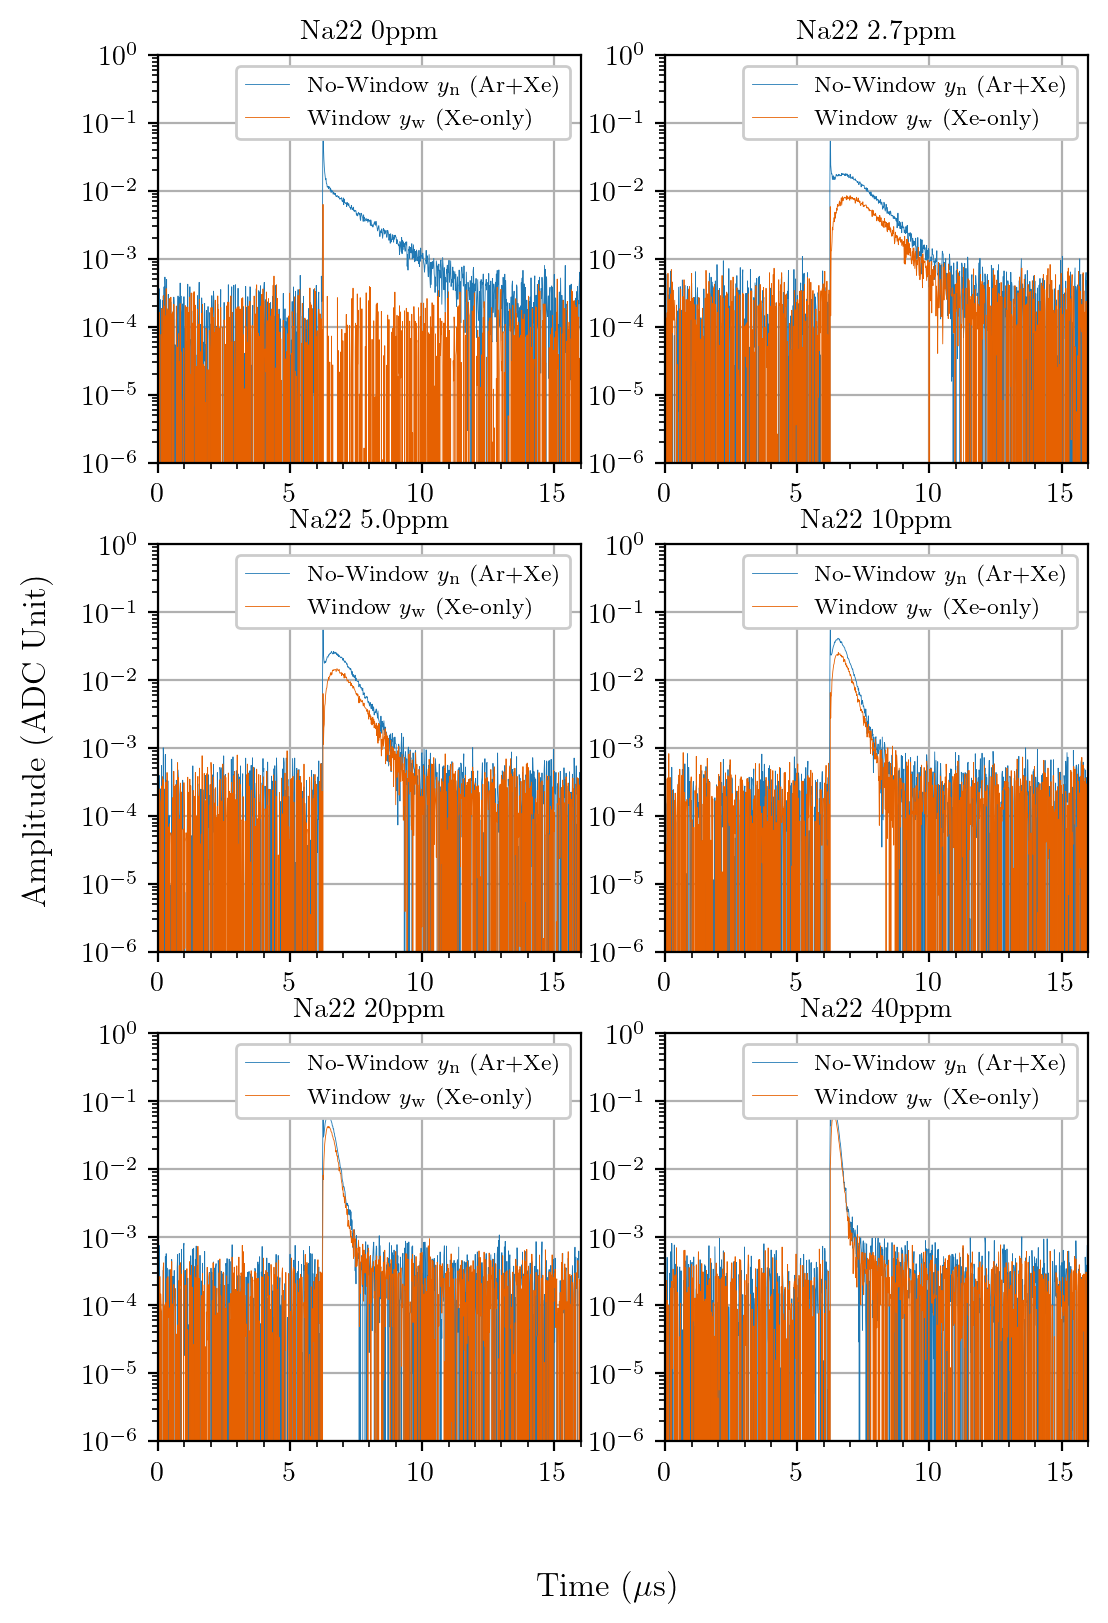

In [324]:
# Make plots for all datasets
# Summed scintillation waveform
fig, axs = plt.subplots(3, 2, sharex=False, sharey=False)
fig.set_size_inches(6, 9)
nofs_total_pe = []
fs_total_pe = []
for i, c in enumerate(cond):
    axs[i//2,i%2].plot(
                data_scint[i][-1]['time_sub'],
                data_scint[i][-1]['sum_wf_sub_nofs'],
                linewidth=0.3,label=r'No-Window $y_{\rm n}$ (Ar+Xe)')
    axs[i//2,i%2].plot(
                data_scint[i][-1]['time_sub'],
                data_scint[i][-1]['sum_wf_sub_fs'],
                linewidth=0.3, label=r'Window $y_{\rm w}$ (Xe-only)')
    axs[i//2,i%2].set_xlim(0,16)
    axs[i//2,i%2].set_ylim(1e-6, 1e0)
    axs[i//2,i%2].set_yscale('log')
    axs[i//2,i%2].minorticks_on()
    axs[i//2,i%2].grid()
    axs[i//2,i%2].set_title(f'{c}')
    axs[i//2,i%2].legend(loc='upper right')
    nofs_total_pe.append(np.sum(data_scint[i][-1]['sum_wf_sub_nofs'])*nsub)
    fs_total_pe.append(np.sum(data_scint[i][-1]['sum_wf_sub_fs'])*nsub)
fig.supxlabel(r'Time ($\mu$s)', y=0.02)
fig.supylabel(r'Amplitude (ADC Unit)', x=0.01)
nofs_total_pe = np.array(nofs_total_pe)
fs_total_pe = np.array(fs_total_pe)

## Fitting

Use ww_model opposite-sign double exponential to fit WW.

In [325]:
def exp_func(x,a,tau):
    return a/tau*np.exp(-x/tau) * 16e-3

file_indices = np.arange(1,len(files)) # exclude 0ppm data
t0 = 6.22
pars, perrs = [], []

for i in file_indices:
    # error estimate
	pretrg = 5 #us
	err = np.std(data_scint[i][-1]['sum_wf_sub_fs'][data_scint[i][-1]['time_sub']<pretrg])
	# set fit range
	sample_left = np.argmax(data_scint[i][-1]['sum_wf_sub_fs']*(data_scint[i][-1]['time_sub']>=6.3)) # maximum after prompt peak
	t_left = data_scint[i][-1]['time_sub'][sample_left]
	t_left = t_left + 0.1*(t_left-t_trig) # time at maximum x 1.8
	sample_right = np.sum(np.cumsum(data_scint[i][-1]['sum_wf_sub_fs'])/np.sum(data_scint[i][-1]['sum_wf_sub_fs'])<0.97) # leave out 10% charge to the right
	t_right = data_scint[i][-1]['time_sub'][sample_right]
	fit_range = [t_left, t_right] #us
	data_scint[i][-1]['fit_range_ww'] = fit_range
	range_arr = (data_scint[i][-1]['time_sub']<fit_range[1]) & (data_scint[i][-1]['time_sub']>fit_range[0])
	# fit setup
	xdata = data_scint[i][-1]['time_sub'][range_arr]
	ydata = data_scint[i][-1]['sum_wf_sub_fs'][range_arr] + 0.015*data_scint[i][-1]['sum_wf_sub_nofs'][range_arr]
	data_scint[i][-1]['sum_wf_sub_fs_err'] = err
	yerr = err*np.ones(np.sum(range_arr))
	p0 = [6.24,np.abs(np.sum(ydata)), 3/conc[i], 2/conc[i]]
	# fit	
	# popt, pcov = curve_fit(lambda x,*p: exp_func(x-t_trig,*p), xdata, ydata, p0=p0, sigma=yerr, maxfev=10000) 
	popt, pcov = curve_fit(lambda x,t_trig,*p: func.ww_model(x-t_trig,*p), xdata, ydata, p0=p0, sigma=yerr, maxfev=10000) 
	perr = np.array([func.error_distance(df=len(p0), sigma=1)*pcov[j,j]**0.5 for j in range(len(popt))])
	print(f'{i} {cond[i]} {p0} {popt} {perr}')
	pars.append(popt)
	perrs.append(perr)

1 Na22 2.7ppm [6.24, 0.6337729160479801, 1.111111111111111, 0.7407407407407407] [6.36711942 0.9197075  1.00528225 0.38105131] [0.36562095 0.17769128 0.10532781 0.19723961]
2 Na22 5.0ppm [6.24, 0.7054932871400337, 0.6, 0.4] [6.42084289 0.97365857 0.61988441 0.23584272] [0.16139049 0.13201828 0.05074577 0.09142158]
3 Na22 10ppm [6.24, 0.7804492574718861, 0.3, 0.2] [6.3627552  1.01532912 0.33742238 0.15989469] [0.05366795 0.07458068 0.02877983 0.04192854]
4 Na22 20ppm [6.24, 0.8293675660817615, 0.15, 0.1] [6.32285949 1.06296298 0.1831382  0.11178389] [0.02223087 0.05370942 0.01989715 0.02532608]
5 Na22 40ppm [6.24, 0.8392242601770109, 0.075, 0.05] [6.31107145 0.97721589 0.12188472 0.0616717 ] [0.00869321 0.0289457  0.00697504 0.00886714]


Text(0.5, 1.0, '$^{22}\\rm Na$, WW Channels')

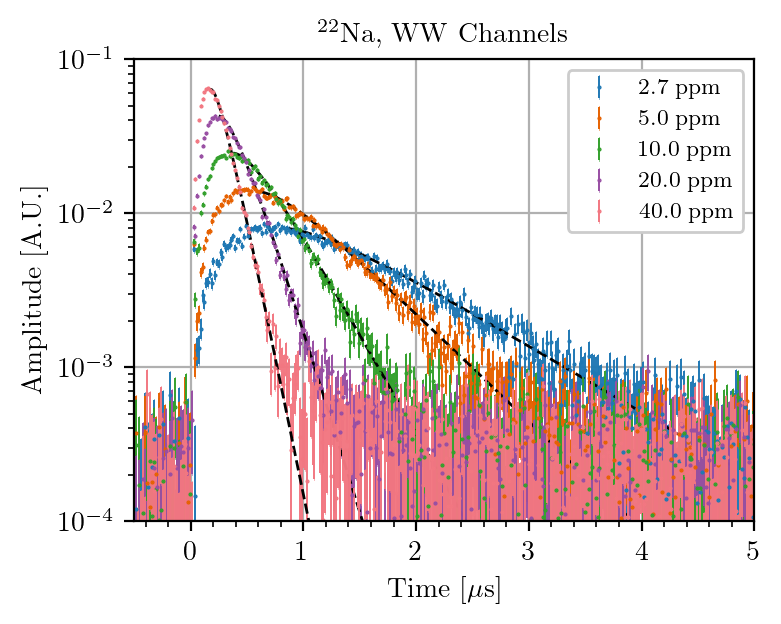

In [326]:
t0 = 6.22
for i_fit in range(len(file_indices)):
	t_trig = pars[i_fit][0]
	i = file_indices[i_fit]
	p = pars[i_fit]
	plt.errorbar(
		data_scint[i][-1]['time_sub']-t0,
		data_scint[i][-1]['sum_wf_sub_fs'],
		yerr=data_scint[i][-1]['sum_wf_sub_fs_err'],
		fmt='.', markersize=1, linewidth=0.7, capsize=0.1, label=f'{conc[i]} ppm')
	mask = (data_scint[i][-1]['time_sub']>data_scint[i][-1]['fit_range_ww'][0]) & (data_scint[i][-1]['time_sub']<data_scint[i][-1]['fit_range_ww'][1])
	plt.plot(data_scint[i][-1]['time_sub'][mask]-t0, 
		func.ww_model(data_scint[i][-1]['time_sub'][mask]-t_trig,*pars[i_fit][1:]),
		color='k', linestyle='--', linewidth=1)

plt.xlim(-0.5,5)
plt.ylim(1e-4,1e-1)
plt.yscale('log')
plt.grid()
plt.minorticks_on()
plt.legend(loc='upper right')
plt.xlabel(r'Time [$\rm \mu s$]')
plt.ylabel(r'Amplitude [A.U.]')
plt.title(r'$^{22}\rm Na$, WW Channels')

Reaction rate constant k=0.26 $\pm$0.01 $\rm \mu s^{-1} ppm^{-1}$
ArXe lifetime $\tau_{ArXe}=$ 3.45\pm0.43 $\rm \mu s


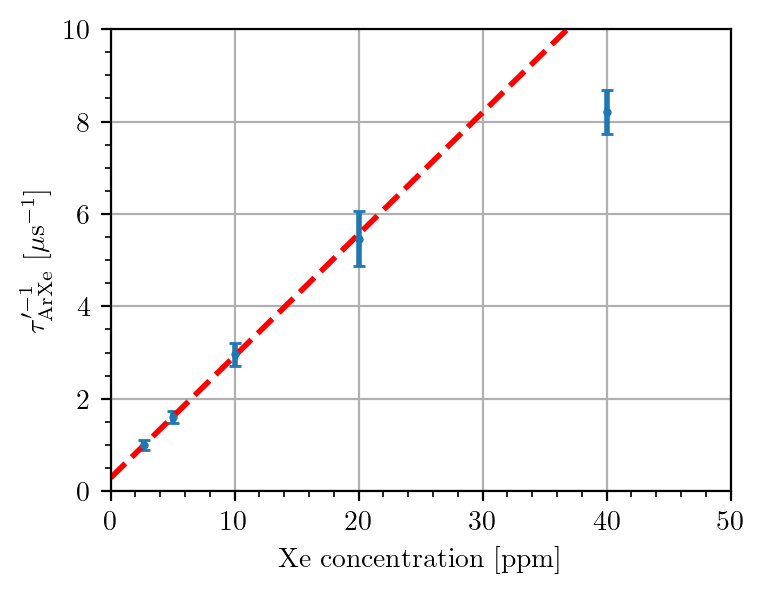

In [327]:
tau_inv = [1/np.abs(p[2]) for p in pars]
tau_inv_err = [e[2]/p[2]**2 for e,p in zip(perrs,pars)]
plt.errorbar(conc[file_indices], tau_inv, yerr=tau_inv_err, linestyle='', linewidth=2, fmt='o', markersize=2, capsize=2)
plt.xlim(0,50)
plt.ylim(0,10)
plt.grid()
plt.minorticks_on()
plt.xlabel('Xe concentration [ppm]')
plt.ylabel(r'$\tau_{\rm ArXe}^{\prime -1}$ [$\rm \mu s^{-1}$]')

popt,pcov = curve_fit(lambda x,a,b: a*x+b, conc[file_indices][:-1], tau_inv[:-1], sigma=tau_inv_err[:-1])
xarr = np.linspace(0,50,100)
plt.plot(xarr, popt[0]*xarr+popt[1], 'r--')
k_rate, k_rate_err = popt[0], func.error_distance(df=2,sigma=1)*pcov[0,0]**0.5
tau_arxe0, tau_arxe0_err = 1/popt[1], func.error_distance(df=2,sigma=1)*pcov[1,1]**0.5/popt[1]**2
print(f'Reaction rate constant k={k_rate:.2f} ' + r'$\pm$' + f'{k_rate_err:.2f} ' + r'$\rm \mu s^{-1} ppm^{-1}$')
print(r'ArXe lifetime $\tau_{ArXe}=$ ' + f'{tau_arxe0:.2f}' + r'\pm' + f'{tau_arxe0_err:.2f} ' + r'$\rm \mu s')

# Estimate Xe concentration in each Co-60 monitoring dataset

## Load Data

Use Co-60 datasets

In [329]:
S_PER_HR = 3600

dt_xe = [
	datetime(2024,2,28,16,33,0),
	datetime(2024,3,6,15,0,0),
	datetime(2024,3,12,17,11,0),
	datetime(2024,3,19,15,0,0),
	datetime(2024,3,25,20,0,0)
]
hr_dt_xe = [(dt_xe[i]-dt_xe[0]).total_seconds()/S_PER_HR for i in range(1,len(dt_xe))]

for i,t in enumerate(dt_xe):
    print(f'Xenon injection #{i+1} at {t} ' + (f'({hr_dt_xe[i-1]:.0f} hr after #1)' if i>0 else ''))

Xenon injection #1 at 2024-02-28 16:33:00 
Xenon injection #2 at 2024-03-06 15:00:00 (166 hr after #1)
Xenon injection #3 at 2024-03-12 17:11:00 (313 hr after #1)
Xenon injection #4 at 2024-03-19 15:00:00 (478 hr after #1)
Xenon injection #5 at 2024-03-25 20:00:00 (627 hr after #1)


In [330]:
# Xe injection monitoring
path = "/scratch/gpfs/GALBIATI/as111/results/"
dates = ['2024-02-28','2024-03-01','2024-03-04', # injection #1
         '2024-03-06','2024-03-08', '2024-03-11', # injection #2
         '2024-03-12','2024-03-18', # injection #3
         '2024-03-19', # injection #4
         '2024-03-25'  # injection #5
        ]
files = []
for d in dates:
    files.extend(glob.glob(f"{path}{d}/*cond_monitor*scintillation_waveform_liq6.h5"))
for i,f in enumerate(files):
    files[i] = [files[i]]
print(len(files),files)

249 [['/scratch/gpfs/GALBIATI/as111/results/2024-02-28/2024-02-28_volt_98_light_scintillation_cond_monitor_source_co60_xenon_1_run11_scintillation_waveform_liq6.h5'], ['/scratch/gpfs/GALBIATI/as111/results/2024-02-28/2024-02-28_volt_98_light_scintillation_cond_monitor_source_co60_xenon_1_run8_scintillation_waveform_liq6.h5'], ['/scratch/gpfs/GALBIATI/as111/results/2024-02-28/2024-02-28_volt_98_light_scintillation_cond_monitor_source_co60_xenon_1_run7_scintillation_waveform_liq6.h5'], ['/scratch/gpfs/GALBIATI/as111/results/2024-02-28/2024-02-28_volt_98_light_scintillation_cond_monitor_source_co60_xenon_1_run5_scintillation_waveform_liq6.h5'], ['/scratch/gpfs/GALBIATI/as111/results/2024-02-28/2024-02-28_volt_98_light_scintillation_cond_monitor_source_co60_xenon_1_run4_scintillation_waveform_liq6.h5'], ['/scratch/gpfs/GALBIATI/as111/results/2024-02-28/2024-02-28_volt_98_light_scintillation_cond_monitor_source_co60_xenon_1_run10_scintillation_waveform_liq6.h5'], ['/scratch/gpfs/GALBIATI/as

In [332]:
# data folder
data_scint = {}
date_time = {}
channels = np.arange(8)
channels_nofs = [1,2,4,7] 
channels_fs = [0,3,6]
ch_old = [0,5,6,3,4,1,2,7] # map to channels in liq5 calibration data
volt = 98
for i,fs in enumerate(files):
    data_scint[i] = {}
    for j,f in enumerate(fs):
        df = pd.read_hdf(f, key=f'{volt}/-1')
        if j==0:
            date_time[i] = datetime(*np.array(df['start_datetime'][:6]).astype(int))
        for ch in channels:
            if j==0:
                data_scint[i][ch] = {'n_scint_wfs':0, 'avg_scint_wf':np.zeros(0), 'time':np.zeros(0)}
            df = pd.read_hdf(f, key=f'{volt}/{ch}')
            data_scint[i][ch]['n_scint_wfs'] += np.array(df['n_scint_wfs'])[0]
            if data_scint[i][ch]['time'].shape[0]==0:
                data_scint[i][ch]['time'] = np.array(df['time'].dropna())
            if data_scint[i][ch]['avg_scint_wf'].shape[0]==0:
                data_scint[i][ch]['avg_scint_wf'] = np.array(df['avg_scint_wf'].dropna())*np.array(df['n_scint_wfs'])[0]
            else:
                data_scint[i][ch]['avg_scint_wf'] += np.array(df['avg_scint_wf'].dropna())*np.array(df['n_scint_wfs'])[0]
            df = None
            data_scint[i][ch]['avg_scint_wf'] /= data_scint[i][ch]['n_scint_wfs']
# sort according to date time
args = np.array(list(date_time.values())).argsort()
files = [files[i] for i in args]
data_scint = [data_scint[i] for i in args]
date_time = [date_time[i] for i in args]
hr_from_inject = [(dt-dt_xe[0]).total_seconds()/S_PER_HR for dt in date_time]

## Processing

* Deconvolution channel-by-channel
* Sum over channels (WL and WW respectively)
* Down-sampling

In [333]:
# Deconvolution channel by channel
for i, f in enumerate(files):
    for j, ch in enumerate(channels):
        if data_scint[i][ch]['n_scint_wfs']>0 and data_spe[ch_old[ch]]['n_spe_wfs']>0:
            dt = data_spe[ch_old[ch]]['time'][1]-data_spe[ch_old[ch]]['time'][0]
            shift = np.array([np.exp(complex(0,-2*np.pi*freq*dt*int(t0_spe[ch_old[ch]]/dt))) for freq in data_spe[ch_old[ch]]['frequency']])
            data_scint[i][ch]['deconv'] = ifft(fft(data_scint[i][ch]['avg_scint_wf'])/data_spe[ch_old[ch]]['fft_spe_wf']*shift).real

In [334]:
# summation
for i,f in enumerate(files):
    data_scint[i][-1] = {'time': data_scint[i][0]['time'], 'sum_wf_nofs': np.zeros(data_scint[i][0]['time'].shape[0]),'sum_wf_fs': np.zeros(data_scint[i][0]['time'].shape[0])}
    for ch in channels_nofs:    
        if data_scint[i][ch]['n_scint_wfs']>0 and data_spe[ch]['n_spe_wfs']>0:
            data_scint[i][-1]['sum_wf_nofs'] += data_scint[i][ch]['deconv']
    for ch in channels_fs:
        if data_scint[i][ch]['n_scint_wfs']>0 and data_spe[ch]['n_spe_wfs']>0:
            data_scint[i][-1]['sum_wf_fs'] += data_scint[i][ch]['deconv']

In [335]:
# subsampling
nsub = 4
for i,f in enumerate(files):
    data_scint[i][-1]['time_sub'], data_scint[i][-1]['sum_wf_sub_nofs'] = func.downsample(data_scint[i][-1]['time'],data_scint[i][-1]['sum_wf_nofs'],nsub)
    data_scint[i][-1]['time_sub'], data_scint[i][-1]['sum_wf_sub_fs'] = func.downsample(data_scint[i][-1]['time'],data_scint[i][-1]['sum_wf_fs'],nsub)

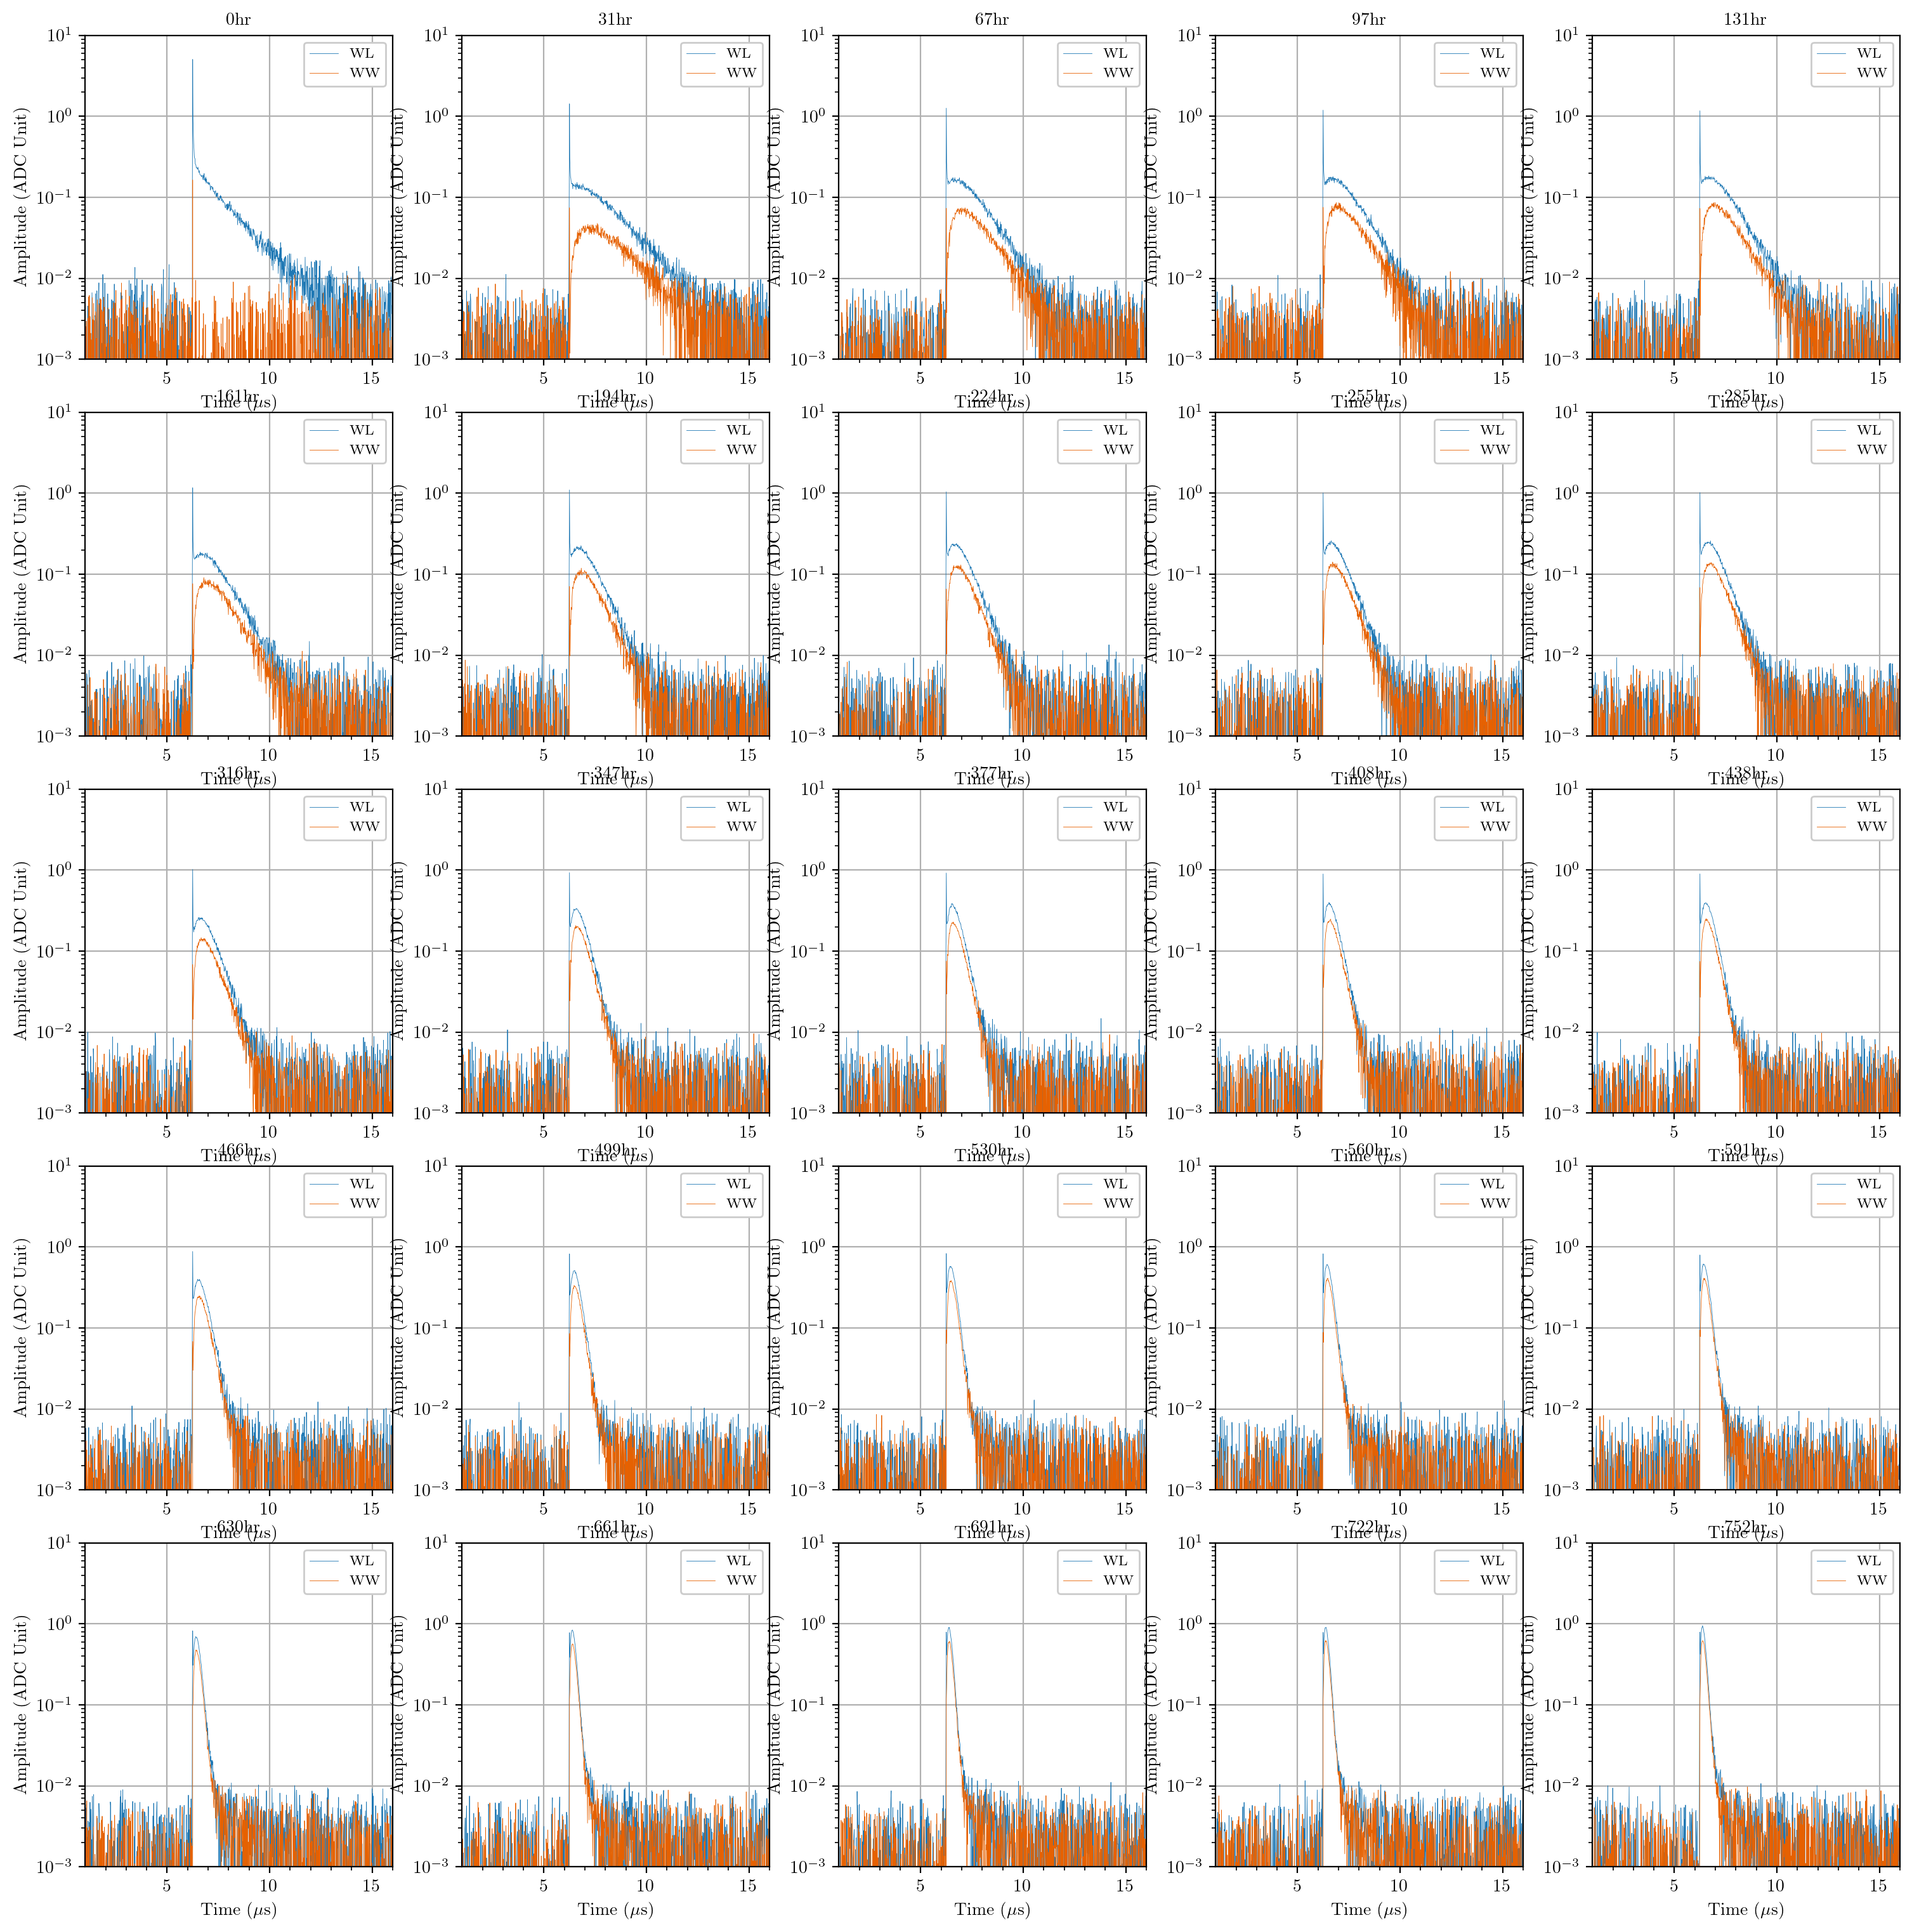

In [336]:
# Make plots for all datasets
# Summed scintillation waveform
file_indices = np.arange(0,len(files),10)
nrows = (len(file_indices)+4)//5
fig, axs = plt.subplots(nrows, 5, sharex=False, sharey=False)
fig.set_size_inches(15, 3*nrows)
fig.tight_layout()

for i, i_file in enumerate(file_indices):
	f = files[i_file]
	axs[i//5, i%5].plot(
				data_scint[i_file][-1]['time_sub'],
				data_scint[i_file][-1]['sum_wf_sub_nofs'],
				linewidth=0.3,label=r'WL')
	axs[i//5, i%5].plot(
				data_scint[i_file][-1]['time_sub'],
				data_scint[i_file][-1]['sum_wf_sub_fs'],
				linewidth=0.3, label=r'WW')
	axs[i//5, i%5].set_xlim(1, 16)
	axs[i//5, i%5].set_ylim(1e-3, 1e1)
	axs[i//5, i%5].set_yscale('log')
	axs[i//5, i%5].minorticks_on()
	axs[i//5, i%5].grid()
	axs[i//5, i%5].set_title(f'{hr_from_inject[i_file]:.0f}hr')
	axs[i//5, i%5].legend(loc='upper right')
	axs[i//5, i%5].set_xlabel(r'Time ($\mu$s)')
	axs[i//5, i%5].set_ylabel(r'Amplitude (ADC Unit)')

## Fitting

Use ww_model opposite-sign double exponential to fit WW.

In [339]:
file_indices = np.arange(5,len(files),1) # exclude 0ppm data
t0 = 6.22
pars, perrs = [], []

for i in file_indices:
    # error estimate
	pretrg = 5 #us
	err = np.std(data_scint[i][-1]['sum_wf_sub_fs'][data_scint[i][-1]['time_sub']<pretrg])
	# set fit range
	sample_left = np.argmax(data_scint[i][-1]['sum_wf_sub_fs']*(data_scint[i][-1]['time_sub']>=6.3)) # maximum after prompt peak
	t_left = data_scint[i][-1]['time_sub'][sample_left]
	t_left = t_left + 0.1*(t_left-t_trig) # time at maximum x 1.8
	sample_right = np.sum(np.cumsum(data_scint[i][-1]['sum_wf_sub_fs'])/np.sum(data_scint[i][-1]['sum_wf_sub_fs'])<0.97) # leave out 10% charge to the right
	t_right = data_scint[i][-1]['time_sub'][sample_right]
	fit_range = [t_left, t_right] #us
	data_scint[i][-1]['fit_range_ww'] = fit_range
	range_arr = (data_scint[i][-1]['time_sub']<fit_range[1]) & (data_scint[i][-1]['time_sub']>fit_range[0])
	# fit setup
	xdata = data_scint[i][-1]['time_sub'][range_arr]
	ydata = data_scint[i][-1]['sum_wf_sub_fs'][range_arr] + 0.015*data_scint[i][-1]['sum_wf_sub_nofs'][range_arr]
	data_scint[i][-1]['sum_wf_sub_fs_err'] = err
	yerr = err*np.ones(np.sum(range_arr))
	if hr_from_inject[i]<hr_dt_xe[0]:
		p0 = [t0,np.abs(np.sum(ydata)), 1, 0.5]
	elif hr_from_inject[i]<hr_dt_xe[1]:
		p0 = [t0,np.abs(np.sum(ydata)), 0.6, 0.3]
	elif hr_from_inject[i]<hr_dt_xe[2]:
		p0 = [t0,np.abs(np.sum(ydata)), 0.4, 0.2]
	elif hr_from_inject[i]<hr_dt_xe[3]:
		p0 = [t0,np.abs(np.sum(ydata)), 0.18, 0.12]
	else:
		p0 = [t0,np.abs(np.sum(ydata)), 0.12, 0.07]
	# fit	
	# popt, pcov = curve_fit(lambda x,*p: exp_func(x-t_trig,*p), xdata, ydata, p0=p0, sigma=yerr, maxfev=10000) 
	popt, pcov = curve_fit(lambda x,t_trig,*p: func.ww_model(x-t_trig,*p), xdata, ydata, p0=p0, sigma=yerr, maxfev=10000) 
	perr = np.array([func.error_distance(df=len(p0), sigma=1)*pcov[j,j]**0.5 for j in range(len(popt))])
	if popt[3]>popt[2]:
		popt[3], popt[2] = popt[2], popt[3]
		perr[3], perr[2] = perr[2], perr[3]
	print(f'{i} {hr_from_inject[i]:.0f}hr {p0} {popt} {perr}')
	pars.append(popt)
	perrs.append(perr)

5 15hr [6.22, 2.8516954194399795, 1, 0.5] [6.85219906 4.91485215 2.51832925 0.53565244] [ 9.75041869 12.89989479  0.69442097  2.88203772]
6 18hr [6.22, 4.043479953723283, 1, 0.5] [6.19951897 6.28227319 2.08878502 0.84128331] [2.091094   3.25206696 0.69833786 1.2031045 ]
7 22hr [6.22, 5.618438192055353, 1, 0.5] [6.40524119 6.70157939 1.99121375 0.65331608] [0.34145434 0.47142128 0.29124828 0.31519798]
8 25hr [6.22, 5.134434265060722, 1, 0.5] [6.64633882 6.51939504 1.91212064 0.47067266] [0.66868567 1.17553607 0.24119019 0.37533821]
9 28hr [6.22, 5.288839997029742, 1, 0.5] [6.37647786 7.37521893 1.70413107 0.61716766] [0.79797152 1.72898046 0.30282417 0.48773123]
10 31hr [6.22, 4.500312967294663, 1, 0.5] [5.98144233 8.56444466 1.47433901 0.86459751] [2.39810662 7.16381033 0.92852672 1.53521549]
11 34hr [6.22, 5.055822727411488, 1, 0.5] [6.389051   7.71196737 1.49147605 0.59228759] [1.0989838  3.01930265 0.31908243 0.59372547]
12 44hr [6.22, 5.837341237255732, 1, 0.5] [6.42586727 8.18912 

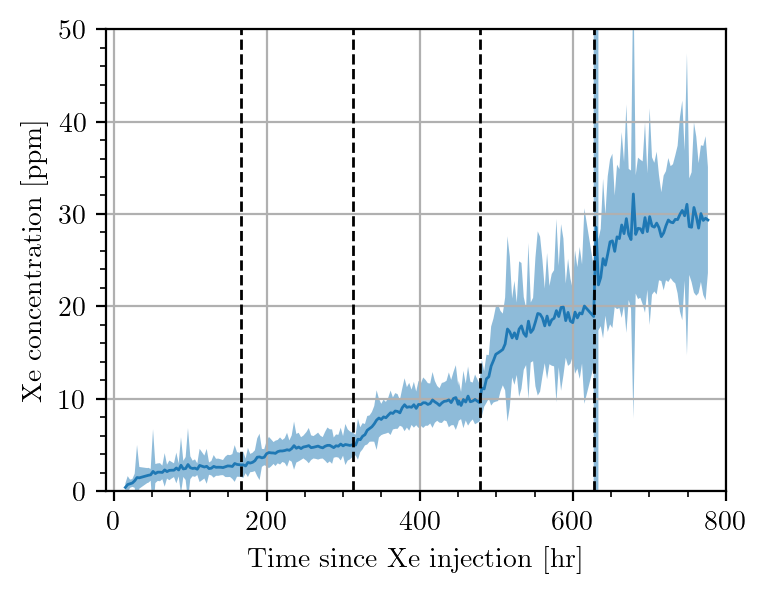

In [340]:
conc_est = np.array([(1/np.abs(p[2]) - tau_arxe0**-1)/k_rate for p in pars])
conc_est_err = np.array([np.abs(c*(e[2]/p[2]/k_rate)) for e,p,c in zip(perrs,pars,conc_est)])
plt.fill_between(np.array(hr_from_inject)[file_indices], conc_est+conc_est_err, conc_est-conc_est_err,alpha=0.5)
plt.plot(np.array(hr_from_inject)[file_indices], conc_est, linewidth=1)
plt.grid()
plt.minorticks_on()
plt.xlabel('Time since Xe injection [hr]')
plt.ylabel('Xe concentration [ppm]')
plt.ylim(0,50)
plt.xlim(-10, 800)
for t in hr_dt_xe:
    plt.plot([t]*2, [0,50], 'k--', lw=1)

# Something else

## Save triplet lifetime vs Xe concentration to an h5 file

In [38]:
store_out = pd.HDFStore('data/tau_Xe_liq6.h5')
xe = np.array([0, 2.7, 5.0, 10, 20, 40])
xe_err = xe*0.2
tau = [data_scint[i][-1]['pars'][1] for i in range(len(xe))]
tau_err = [data_scint[i][-1]['pars_err'][1] for i in range(len(xe))]
df = pd.DataFrame({'Xe [ppm]':xe,'Xe err [ppm]':xe_err,'Tau [us]':tau,'Tau err [us]':tau_err})
store_out.put('liq6',df)
store_out.close()